### Weather Data Compression and Clustering
### Bashar Albaalbaki
### Coursera Project
### IBM Machine Learning Certificate Series
### Course #4: Unsupervised Machine Learning
### Final Project


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score, contingency_matrix
from sklearn.manifold import MDS
from sklearn.cluster import KMeans, DBSCAN, MeanShift
import time

In [2]:
cities = ["Austin", "Calgary", "Lincoln_NB", "Lisbon", "LosAngeles", "Paris"]
df_cities_list = []
for city in cities:
    file_name = f"data/{city}_weather.csv"
    df_city = pd.read_csv(file_name)
    df_city["city"] = city
    df_cities_list.append(df_city)
df_cities_list[0].sample(5)

,timestamp,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,surface_pressure,city
601,2023-01-26 01:00:00,-3.6,40,0.0,0.0,0.0,0.0,0.00,-15.2,7.1,246,45.4,59,602.1,Austin
11197,2024-04-11 13:00:00,-3.8,57,0.0,0.0,0.0,0.0,0.07,-11.2,5.9,227,26.6,0,607.4,Austin
597,2023-01-25 21:00:00,-6.4,54,0.0,0.0,0.0,0.0,0.00,-14.1,11.8,247,51.1,38,598.4,Austin
10083,2024-02-25 03:00:00,-5.0,41,0.0,0.0,0.0,0.0,0.03,-16.3,15.6,230,59.0,2,601.8,Austin
8877,2024-01-05 21:00:00,-18.5,64,0.0,0.0,0.0,0.0,0.01,-23.7,12.8,238,32.0,0,590.3,Austin


In [3]:
for df_city in df_cities_list:
    city = df_city["city"][0]
    num_rows_with_nan = df_city.isnull().any(axis=1).sum()
    print(f"City: {city}, Number of rows with a NaN = {num_rows_with_nan}")
    if num_rows_with_nan:
        num_rows_with_nan_snow = df_city[["snow_depth"]].isnull().any(axis=1).sum()
        print(f"                  Number of rows with a NaN in snow_depth column = {num_rows_with_nan_snow}")
        num_rows_with_nan_others = df_city.drop(columns=["snow_depth"]).isnull().any(axis=1).sum()
        print(f"                  Number of rows with a NaN in other column = {num_rows_with_nan_others}")

City: Austin, Number of rows with a NaN = 0
City: Calgary, Number of rows with a NaN = 0
City: Lincoln_NB, Number of rows with a NaN = 0
City: Lisbon, Number of rows with a NaN = 17544
                  Number of rows with a NaN in snow_depth column = 17544
                  Number of rows with a NaN in other column = 0
City: LosAngeles, Number of rows with a NaN = 0
City: Paris, Number of rows with a NaN = 0


In [4]:
df_cities_list[1].sample(5)

,timestamp,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,surface_pressure,city
12651,2024-06-11 03:00:00,19.7,49,0.0,0.0,0.0,0.0,0.00,8.5,3.8,73,16.2,89,915.4,Calgary
5527,2023-08-19 07:00:00,19.8,45,0.0,0.0,0.0,0.0,0.00,7.7,22.3,272,49.7,53,916.3,Calgary
17521,2024-12-31 01:00:00,-12.9,78,0.0,0.0,0.0,0.0,0.10,-16.0,20.9,304,37.1,53,916.8,Calgary
15771,2024-10-19 03:00:00,-1.1,25,0.0,0.0,0.0,0.0,0.02,-18.9,8.8,213,24.8,0,938.5,Calgary
3650,2023-06-02 02:00:00,16.5,37,0.0,0.0,0.0,0.0,0.00,1.7,11.0,341,31.0,4,925.0,Calgary


In [5]:
df_cities_list[2].sample(5)

,timestamp,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,surface_pressure,city
5606,2023-08-22 14:00:00,21.3,30,0.0,0.0,0.0,0.0,0.00,3.3,19.5,87,25.9,43,840.2,Lincoln_NB
4475,2023-07-06 11:00:00,30.9,11,0.0,0.0,0.0,0.0,0.00,-3.6,7.8,103,20.5,1,836.9,Lincoln_NB
4467,2023-07-06 03:00:00,27.1,15,0.0,0.0,0.0,0.0,0.00,-2.0,18.3,74,37.4,100,839.3,Lincoln_NB
347,2023-01-15 11:00:00,-14.3,38,0.0,0.0,0.0,0.0,0.01,-25.7,27.6,262,42.8,72,848.6,Lincoln_NB
8496,2023-12-21 00:00:00,-18.0,47,0.0,0.0,0.0,0.0,0.01,-26.7,15.2,76,21.6,83,848.5,Lincoln_NB


In [6]:
df_cities_list[3].sample(5)

,timestamp,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,surface_pressure,city
14958,2024-09-15 06:00:00,20.0,66,0.0,0.0,0.0,0.0,NaN,13.4,18.9,309,29.2,0,1016.3,Lisbon
14016,2024-08-07 00:00:00,25.6,83,0.0,0.0,0.0,0.0,NaN,22.5,19.5,39,27.0,0,1011.5,Lisbon
10364,2024-03-07 20:00:00,13.6,81,0.0,0.0,0.0,0.0,NaN,10.4,27.2,97,35.6,100,1015.7,Lisbon
16402,2024-11-14 10:00:00,19.0,70,0.0,0.0,0.0,0.0,NaN,13.4,3.4,295,7.2,1,1019.0,Lisbon
16693,2024-11-26 13:00:00,19.1,77,0.0,0.0,0.0,0.0,NaN,14.9,10.1,204,13.0,5,1021.9,Lisbon


In [7]:
df_cities_list[3].fillna(0, inplace=True)
df_cities_list[3].sample(5)

,timestamp,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,surface_pressure,city
5466,2023-08-16 18:00:00,25.3,88,0.0,0.0,0.0,0.0,0.0,23.1,14.9,127,21.2,0,1015.7,Lisbon
10500,2024-03-13 12:00:00,14.8,71,0.0,0.0,0.0,0.0,0.0,9.4,22.8,291,27.7,6,1019.5,Lisbon
15227,2024-09-26 11:00:00,23.6,85,0.0,0.0,0.0,0.0,0.0,21.0,14.4,179,19.8,0,1016.5,Lisbon
7644,2023-11-15 12:00:00,20.8,77,0.0,0.0,0.0,0.0,0.0,16.5,31.8,280,38.2,66,1019.9,Lisbon
15204,2024-09-25 12:00:00,23.5,79,0.0,0.0,0.0,0.0,0.0,19.7,10.0,247,16.6,0,1016.7,Lisbon


In [8]:
df_cities_list[4].sample(5)

,timestamp,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,surface_pressure,city
3886,2023-06-11 22:00:00,20.7,77,0.0,0.0,0.0,0.0,0.0,16.4,9.1,83,17.6,14,1004.4,LosAngeles
12628,2024-06-10 04:00:00,35.2,32,0.0,0.0,0.0,0.0,0.0,15.8,12.2,166,29.2,54,1003.4,LosAngeles
15502,2024-10-07 22:00:00,11.8,83,0.0,0.0,0.0,0.0,0.0,8.9,8.8,35,14.4,0,1020.5,LosAngeles
2130,2023-03-30 18:00:00,8.1,92,0.0,0.0,0.0,0.0,0.0,6.8,7.5,107,11.9,28,1016.0,LosAngeles
4231,2023-06-26 07:00:00,29.6,55,0.0,0.0,0.0,0.0,0.0,19.5,11.5,316,26.6,57,1001.2,LosAngeles


In [9]:
df_cities_list[5].sample(5)

,timestamp,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,surface_pressure,city
9742,2024-02-10 22:00:00,6.4,92,0.0,0.0,0.0,0.0,0.0,5.3,12.1,203,21.2,100,982.5,Paris
6891,2023-10-15 03:00:00,8.7,92,0.0,0.0,0.0,0.0,0.0,7.5,10.6,294,19.1,11,1016.7,Paris
13183,2024-07-03 07:00:00,14.3,84,0.0,0.0,0.0,0.0,0.0,11.5,8.8,282,20.5,100,1008.4,Paris
11334,2024-04-17 06:00:00,5.3,93,0.0,0.0,0.0,0.0,0.0,4.2,11.9,295,20.9,27,1010.5,Paris
16040,2024-10-30 08:00:00,11.6,93,0.0,0.0,0.0,0.0,0.0,10.5,4.6,72,10.1,91,1022.4,Paris


In [10]:
df_cities = pd.concat(df_cities_list, axis = 0, ignore_index=True)
assert df_cities.shape == (17544 * 5 + 8760, 15)
df_cities.shape

(96480, 15)

In [11]:
df_cities.sample(10)

,timestamp,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,surface_pressure,city
40893,2023-08-30 21:00:00,16.6,56,0.0,0.0,0.0,0.0,0.00,7.9,9.0,270,12.2,78,840.9,Lincoln_NB
19234,2023-03-12 10:00:00,-6.2,21,0.0,0.0,0.0,0.0,0.02,-24.9,10.6,156,24.5,100,921.6,Calgary
12905,2024-06-21 17:00:00,5.9,88,0.0,0.0,0.0,0.0,0.00,4.0,3.6,233,11.2,3,611.7,Austin
22537,2023-07-28 01:00:00,17.2,78,0.1,0.1,0.0,0.0,0.00,13.4,16.6,300,40.0,100,914.5,Calgary
46679,2023-04-28 23:00:00,17.2,89,0.0,0.0,0.0,0.0,0.00,15.4,11.0,122,14.8,88,1017.4,Lisbon
21707,2023-06-23 11:00:00,23.5,59,0.0,0.0,0.0,0.0,0.00,15.0,11.0,341,23.8,98,914.6,Calgary
74546,2024-07-02 02:00:00,24.6,80,0.1,0.1,0.0,0.0,0.00,21.0,21.9,297,40.7,100,993.7,LosAngeles
87803,2024-01-05 11:00:00,8.1,81,0.0,0.0,0.0,0.0,0.00,5.1,14.8,244,28.1,4,998.7,Paris
92752,2024-07-29 16:00:00,29.1,47,0.0,0.0,0.0,0.0,0.00,16.7,12.9,108,25.2,30,1011.8,Paris
16002,2024-10-28 18:00:00,-1.1,53,0.0,0.0,0.0,0.0,0.02,-9.6,7.8,248,38.2,15,607.1,Austin


In [12]:
timestamps = pd.to_datetime(df_cities["timestamp"], format="mixed")
df_cities["day_of_year"] = timestamps.dt.dayofyear
df_cities["hour_of_day"] = timestamps.dt.hour
df_cities.sample(10)

,timestamp,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,surface_pressure,city,day_of_year,hour_of_day
6140,2023-09-13 20:00:00,0.7,69,0.0,0.0,0.0,0.0,0.00,-4.2,4.1,232,15.1,1,610.2,Austin,256,20
42201,2023-10-24 09:00:00,16.3,19,0.0,0.0,0.0,0.0,0.00,-7.2,7.6,239,15.8,0,846.4,Lincoln_NB,297,9
60649,2024-12-01 01:00:00,15.1,57,0.0,0.0,0.0,0.0,0.00,6.7,26.0,24,37.1,0,1025.0,Lisbon,336,1
23981,2023-09-26 05:00:00,10.8,74,0.3,0.3,0.0,0.0,0.00,6.4,16.6,92,40.3,100,914.7,Calgary,269,5
55409,2024-04-26 17:00:00,15.9,91,0.0,0.0,0.0,0.0,0.00,14.4,20.1,80,25.9,2,1009.0,Lisbon,117,17
38234,2023-05-12 02:00:00,15.7,15,0.0,0.0,0.0,0.0,0.00,-10.8,14.9,255,24.8,0,847.2,Lincoln_NB,132,2
33005,2024-10-06 05:00:00,9.2,28,0.0,0.0,0.0,0.0,0.00,-8.4,11.5,240,29.9,8,930.7,Calgary,280,5
8130,2023-12-05 18:00:00,-14.3,66,0.0,0.0,0.0,0.0,0.02,-19.4,8.4,230,20.9,38,601.1,Austin,339,18
59141,2024-09-29 05:00:00,20.5,62,0.0,0.0,0.0,0.0,0.00,13.0,20.4,314,30.6,0,1022.1,Lisbon,273,5
67240,2023-09-01 16:00:00,21.9,94,0.0,0.0,0.0,0.0,0.00,20.9,5.4,82,10.1,0,1010.9,LosAngeles,244,16


In [13]:
df_cities.shape

(96480, 17)

In [14]:
encoder = OneHotEncoder(sparse_output=False)
encoded_city_names = encoder.fit_transform(df_cities[['city']])
encoded_feature_names = encoder.get_feature_names_out()
encoded_df = pd.DataFrame(encoded_city_names, columns=encoded_feature_names)
df_cities = pd.concat([df_cities, encoded_df], axis = 1)
df_cities.shape

(96480, 23)

In [15]:
df_cities.head()

,timestamp,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,...,surface_pressure,city,day_of_year,hour_of_day,city_Austin,city_Calgary,city_Lincoln_NB,city_Lisbon,city_LosAngeles,city_Paris
0,2023-01-01 00:00:00,-10.7,46,0.0,0.0,0.0,0.0,0.01,-20.2,9.2,...,597.8,Austin,1,0,1.0,0.0,0.0,0.0,0.0,0.0
1,2023-01-01 01:00:00,-9.7,42,0.0,0.0,0.0,0.0,0.01,-20.2,5.1,...,599.3,Austin,1,1,1.0,0.0,0.0,0.0,0.0,0.0
2,2023-01-01 02:00:00,-6.5,34,0.0,0.0,0.0,0.0,0.01,-19.9,4.8,...,602.9,Austin,1,2,1.0,0.0,0.0,0.0,0.0,0.0
3,2023-01-01 03:00:00,-4.1,27,0.0,0.0,0.0,0.0,0.01,-20.3,3.3,...,604.9,Austin,1,3,1.0,0.0,0.0,0.0,0.0,0.0
4,2023-01-01 04:00:00,-2.3,22,0.0,0.0,0.0,0.0,0.01,-21.2,6.5,...,605.9,Austin,1,4,1.0,0.0,0.0,0.0,0.0,0.0


In [16]:
le = LabelEncoder()
city_labels = le.fit_transform(df_cities["city"].values)
for label in le.classes_:
    print(f"{label}: label = {le.transform([label])[0]}")

Austin: label = 0
Calgary: label = 1
Lincoln_NB: label = 2
Lisbon: label = 3
LosAngeles: label = 4
Paris: label = 5


In [17]:
df_cities.tail()

,timestamp,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,...,surface_pressure,city,day_of_year,hour_of_day,city_Austin,city_Calgary,city_Lincoln_NB,city_Lisbon,city_LosAngeles,city_Paris
96475,2024-12-31 19:00:00,5.3,88,0.0,0.0,0.0,0.0,0.0,3.6,16.1,...,1022.3,Paris,366,19,0.0,0.0,0.0,0.0,0.0,1.0
96476,2024-12-31 20:00:00,5.6,88,0.0,0.0,0.0,0.0,0.0,3.8,16.5,...,1022.2,Paris,366,20,0.0,0.0,0.0,0.0,0.0,1.0
96477,2024-12-31 21:00:00,5.6,89,0.0,0.0,0.0,0.0,0.0,4.0,16.0,...,1022.1,Paris,366,21,0.0,0.0,0.0,0.0,0.0,1.0
96478,2024-12-31 22:00:00,5.3,93,0.0,0.0,0.0,0.0,0.0,4.2,16.4,...,1021.8,Paris,366,22,0.0,0.0,0.0,0.0,0.0,1.0
96479,2024-12-31 23:00:00,4.9,95,0.0,0.0,0.0,0.0,0.0,4.1,16.0,...,1021.5,Paris,366,23,0.0,0.0,0.0,0.0,0.0,1.0


In [18]:
data = df_cities.drop(columns=["timestamp", "city"])
data.sample(6)

,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,...,cloud_cover,surface_pressure,day_of_year,hour_of_day,city_Austin,city_Calgary,city_Lincoln_NB,city_Lisbon,city_LosAngeles,city_Paris
76249,25.4,91,0.9,0.9,0.0,0.00,0.00,23.8,19.6,26,...,100,1012.4,255,1,0.0,0.0,0.0,0.0,1.0,0.0
64081,11.7,91,0.4,0.4,0.0,0.00,0.00,10.2,20.0,83,...,100,1021.1,113,1,0.0,0.0,0.0,0.0,1.0,0.0
30601,16.7,94,0.7,0.7,0.0,0.00,0.00,15.7,12.1,17,...,100,912.8,180,1,0.0,1.0,0.0,0.0,0.0,0.0
11523,2.2,57,0.5,0.1,0.0,0.28,0.11,-5.4,2.2,9,...,91,611.1,116,3,1.0,0.0,0.0,0.0,0.0,0.0
93681,16.8,85,0.0,0.0,0.0,0.00,0.00,14.2,4.6,129,...,66,1005.7,250,9,0.0,0.0,0.0,0.0,0.0,1.0
6369,14.6,43,0.0,0.0,0.0,0.00,0.00,2.2,11.0,218,...,82,617.4,266,9,1.0,0.0,0.0,0.0,0.0,0.0


In [19]:
data.describe()

,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,...,cloud_cover,surface_pressure,day_of_year,hour_of_day,city_Austin,city_Calgary,city_Lincoln_NB,city_Lisbon,city_LosAngeles,city_Paris
count,96480.000000,96480.000000,96480.000000,96480.000000,96480.0,96480.000000,96480.000000,96480.000000,96480.00000,96480.000000,...,96480.000000,96480.000000,96480.000000,96480.000000,96480.000000,96480.000000,96480.000000,96480.000000,96480.000000,96480.000000
mean,10.191128,64.792475,0.078085,0.071174,0.0,0.004850,0.006407,2.818778,13.82584,200.505037,...,50.610541,907.809518,183.227612,11.500000,0.181841,0.181841,0.090796,0.181841,0.181841,0.181841
std,11.999892,22.317410,0.447457,0.438602,0.0,0.050446,0.018231,13.386592,9.20379,99.609401,...,43.343953,150.759795,105.498380,6.922222,0.385715,0.385715,0.287320,0.385715,0.385715,0.385715
min,-33.100000,3.000000,0.000000,0.000000,0.0,0.000000,0.000000,-39.400000,0.00000,0.000000,...,0.000000,588.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.500000,50.000000,0.000000,0.000000,0.0,0.000000,0.000000,-7.000000,7.30000,107.000000,...,1.000000,844.500000,92.000000,5.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.000000,69.000000,0.000000,0.000000,0.0,0.000000,0.000000,5.400000,11.50000,230.000000,...,48.000000,1001.100000,183.000000,11.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,19.000000,83.000000,0.000000,0.000000,0.0,0.000000,0.000000,12.900000,18.10000,285.000000,...,100.000000,1014.500000,275.000000,17.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,37.200000,100.000000,22.900000,22.900000,0.0,2.240000,0.140000,29.400000,78.00000,360.000000,...,100.000000,1043.100000,366.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
data[["showers"]].describe()

,showers
count,96480.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [19]:
data.corr()

,temperature_2m,relative_humidity_2m,precipitation,rain,showers,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,...,cloud_cover,surface_pressure,day_of_year,hour_of_day,city_Austin,city_Calgary,city_Lincoln_NB,city_Lisbon,city_LosAngeles,city_Paris
temperature_2m,1.000000,0.117965,0.062230,0.076055,NaN,-0.076829,-0.568290,0.874855,0.142602,-0.239244,...,0.079976,0.404066,1.501804e-01,-9.654073e-02,-3.159313e-01,-3.401392e-01,-2.295347e-02,3.504263e-01,2.227235e-01,1.000187e-01
relative_humidity_2m,0.117965,1.000000,0.145107,0.145310,NaN,0.016484,-0.035615,0.566787,-0.080123,-0.035632,...,0.170469,0.388244,1.009126e-01,1.653766e-01,-2.041839e-01,-1.095670e-01,-4.684450e-01,2.774062e-01,9.987368e-02,2.854169e-01
precipitation,0.062230,0.145107,1.000000,0.986974,NaN,0.202107,-0.035964,0.112698,-0.008200,-0.036854,...,0.172131,-0.014287,1.642355e-02,-1.056140e-02,3.428447e-02,-4.262201e-02,-5.046257e-02,-4.141490e-02,4.200754e-02,4.533459e-02
rain,0.076055,0.145310,0.986974,1.000000,NaN,0.041944,-0.054440,0.124441,-0.002385,-0.039611,...,0.162329,0.004968,1.863572e-02,-7.851797e-03,1.489517e-02,-4.378061e-02,-4.760459e-02,-3.482332e-02,4.734238e-02,5.182716e-02
showers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
snowfall,-0.076829,0.016484,0.202107,0.041944,NaN,1.000000,0.108306,-0.057939,-0.036391,0.012328,...,0.081034,-0.119214,-1.160701e-02,-1.776168e-02,1.224322e-01,1.916406e-03,-2.352582e-02,-4.532789e-02,-2.742950e-02,-3.406682e-02
snow_depth,-0.568290,-0.035615,-0.035964,-0.054440,NaN,0.108306,1.000000,-0.486872,-0.046486,0.205429,...,-0.045180,-0.141881,1.480625e-02,-1.732963e-03,6.534011e-02,4.423200e-01,-7.595996e-02,-1.656883e-01,-1.305049e-01,-1.548842e-01
dew_point_2m,0.874855,0.566787,0.112698,0.124441,NaN,-0.057939,-0.486872,1.000000,0.075839,-0.207711,...,0.140878,0.513807,1.761667e-01,-3.698001e-03,-3.431384e-01,-3.267070e-01,-2.787413e-01,4.312696e-01,2.397706e-01,2.064402e-01
wind_speed_10m,0.142602,-0.080123,-0.008200,-0.002385,NaN,-0.036391,-0.046486,0.075839,1.000000,0.092223,...,-0.021766,0.280347,-4.783526e-02,-1.099037e-02,-3.299677e-01,-5.432287e-02,2.071027e-01,4.336520e-01,-1.765793e-01,-2.705345e-02
wind_direction_10m,-0.239244,-0.035632,-0.036854,-0.039611,NaN,0.012328,0.205429,-0.207711,0.092223,1.000000,...,-0.100897,-0.099957,-1.880595e-02,1.797969e-02,8.227907e-02,2.471504e-01,-1.396171e-01,2.287403e-02,-2.310502e-01,-1.725215e-02


In [22]:
data = data.drop(columns=["showers"])

<Axes: >

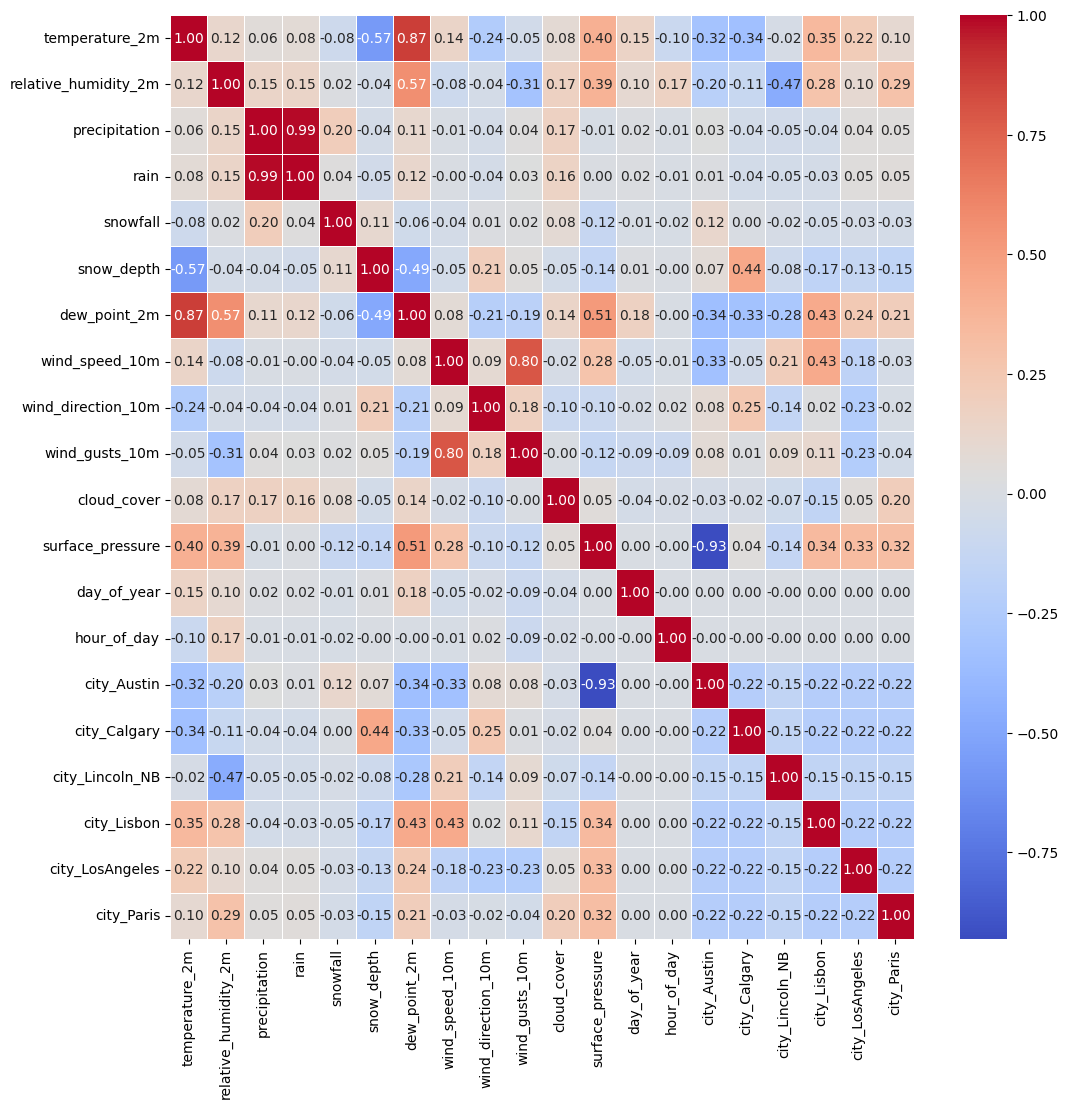

In [26]:
data_corr_matrix = data.corr()
plt.figure(figsize=(12, 12)) # Adjust figure size as needed
sns.heatmap(data_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

In [27]:
data = data.drop(columns = ["rain"])
data.sample(5)

,temperature_2m,relative_humidity_2m,precipitation,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,surface_pressure,day_of_year,hour_of_day,city_Austin,city_Calgary,city_Lincoln_NB,city_Lisbon,city_LosAngeles,city_Paris
88123,-2.3,86,0.0,0.0,0.02,-4.4,9.6,304,16.6,2,1007.8,18,19,0.0,0.0,0.0,0.0,0.0,1.0
10209,1.1,23,0.0,0.0,0.02,-17.6,19.4,252,71.3,0,607.2,61,9,1.0,0.0,0.0,0.0,0.0,0.0
84671,13.9,86,0.0,0.0,0.00,11.6,10.7,284,19.4,27,1008.8,239,23,0.0,0.0,0.0,0.0,0.0,1.0
28670,-0.1,58,0.0,0.0,0.00,-7.3,8.9,159,12.6,92,922.7,99,14,0.0,1.0,0.0,0.0,0.0,0.0
7352,4.9,33,0.0,0.0,0.00,-10.2,10.0,249,30.6,52,611.4,307,8,1.0,0.0,0.0,0.0,0.0,0.0


In [28]:
data.shape

(96480, 19)

In [30]:
X = data.drop(columns=encoder.get_feature_names_out())
X.shape

(96480, 13)

In [31]:
indices = np.arange(X.shape[0])
X_train, X_test, indices_train, indices_test = train_test_split(X.values, indices, test_size = 0.2, random_state = 42)

In [32]:
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)

In [33]:
mms = MinMaxScaler()
X_train_mmscaled = mms.fit_transform(X_train)

# PCA

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
X_pca.shape

(77184, 2)

In [35]:
Xhat_test = ss.inverse_transform(pca.inverse_transform(pca.transform(ss.transform(X_test))))
r2 = r2_score(y_true=X_test, y_pred=Xhat_test)
r2

0.37587289898796483

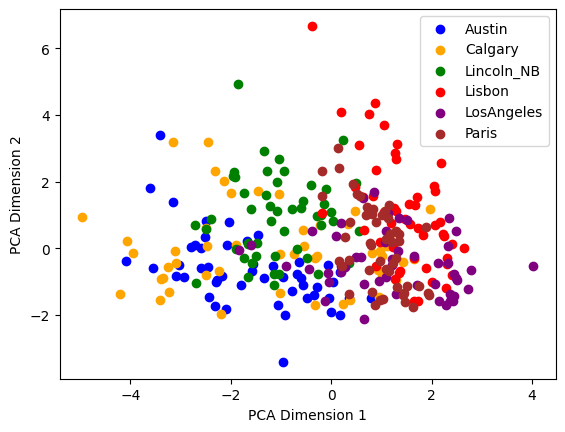

In [36]:
X_2d = pca.transform(ss.transform(X.values))
df_pca_2d = pd.DataFrame()
df_pca_2d["pca_dim_1"] = X_2d[:,0]
df_pca_2d["pca_dim_2"] = X_2d[:,1]
df_pca_2d["city"] = df_cities['city'].values
colors = {"Austin" : "blue", "Calgary" : "orange", "Lincoln_NB":"green","Lisbon":"red","LosAngeles":"purple","Paris":"brown"}
for city in cities:
    df_city = df_pca_2d[df_pca_2d["city"] == city]
    df_city = df_city.sample(50)
    plt.scatter(df_city["pca_dim_1"].values, df_city["pca_dim_2"].values, label=city, color=colors[city])
plt.legend()
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.show()

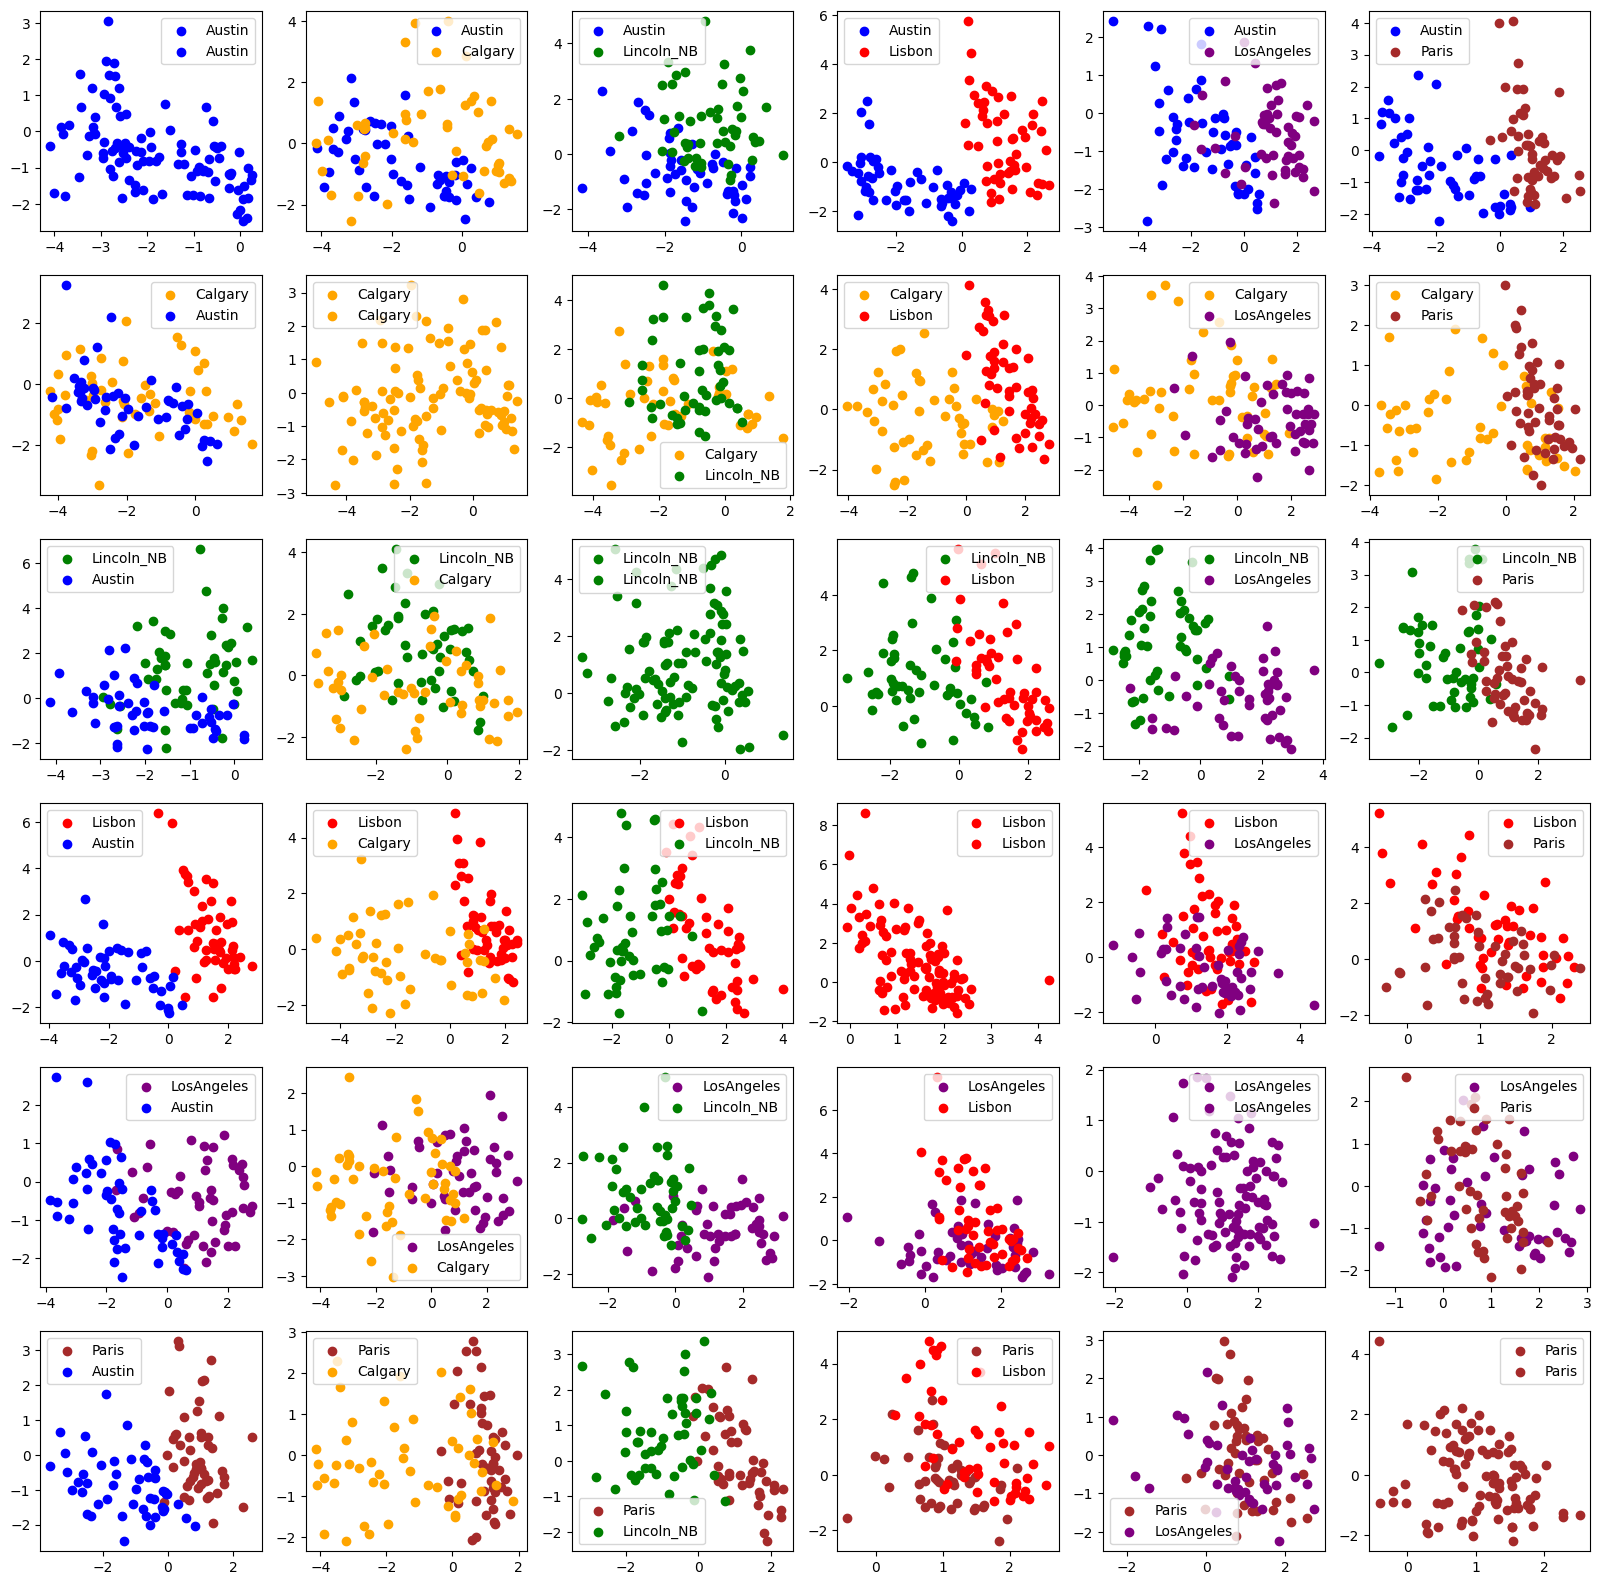

In [29]:
n_cities = len(cities)
fig, ax = plt.subplots(nrows=n_cities, ncols=n_cities, figsize=(20,20))
for i, city1 in enumerate(cities):
    for j, city2 in enumerate(cities):
        for city in [city1, city2]:
            df_city = df_pca_2d[df_pca_2d["city"] == city]
            df_city = df_city.sample(50)
            ax[i][j].scatter(df_city["pca_dim_1"].values, df_city["pca_dim_2"].values, label=city, color=colors[city])
        ax[i][j].legend()
plt.show()

city = Austin , df_city.shape = (50, 3)
city = Calgary , df_city.shape = (50, 3)
city = Lincoln_NB , df_city.shape = (50, 3)
city = Lisbon , df_city.shape = (50, 3)
city = LosAngeles , df_city.shape = (50, 3)
city = Paris , df_city.shape = (50, 3)


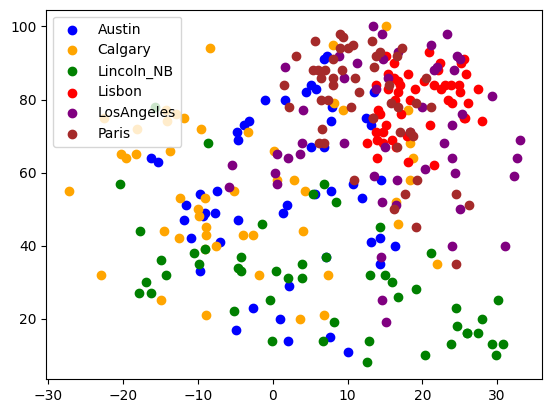

In [30]:
df_2d = pd.DataFrame()
df_2d["temperature_2m"] = df_cities["temperature_2m"].values
df_2d["relative_humidity_2m"] = df_cities["relative_humidity_2m"].values
df_2d["city"] = df_cities['city'].values
for city in cities:
    df_city = df_2d[df_2d["city"] == city]
    df_city = df_city.sample(50)
    print(f"city = {city} , df_city.shape = {df_city.shape}")
    plt.scatter(df_city["temperature_2m"].values, df_city["relative_humidity_2m"].values, label=city, color=colors[city])
plt.legend()
plt.show()

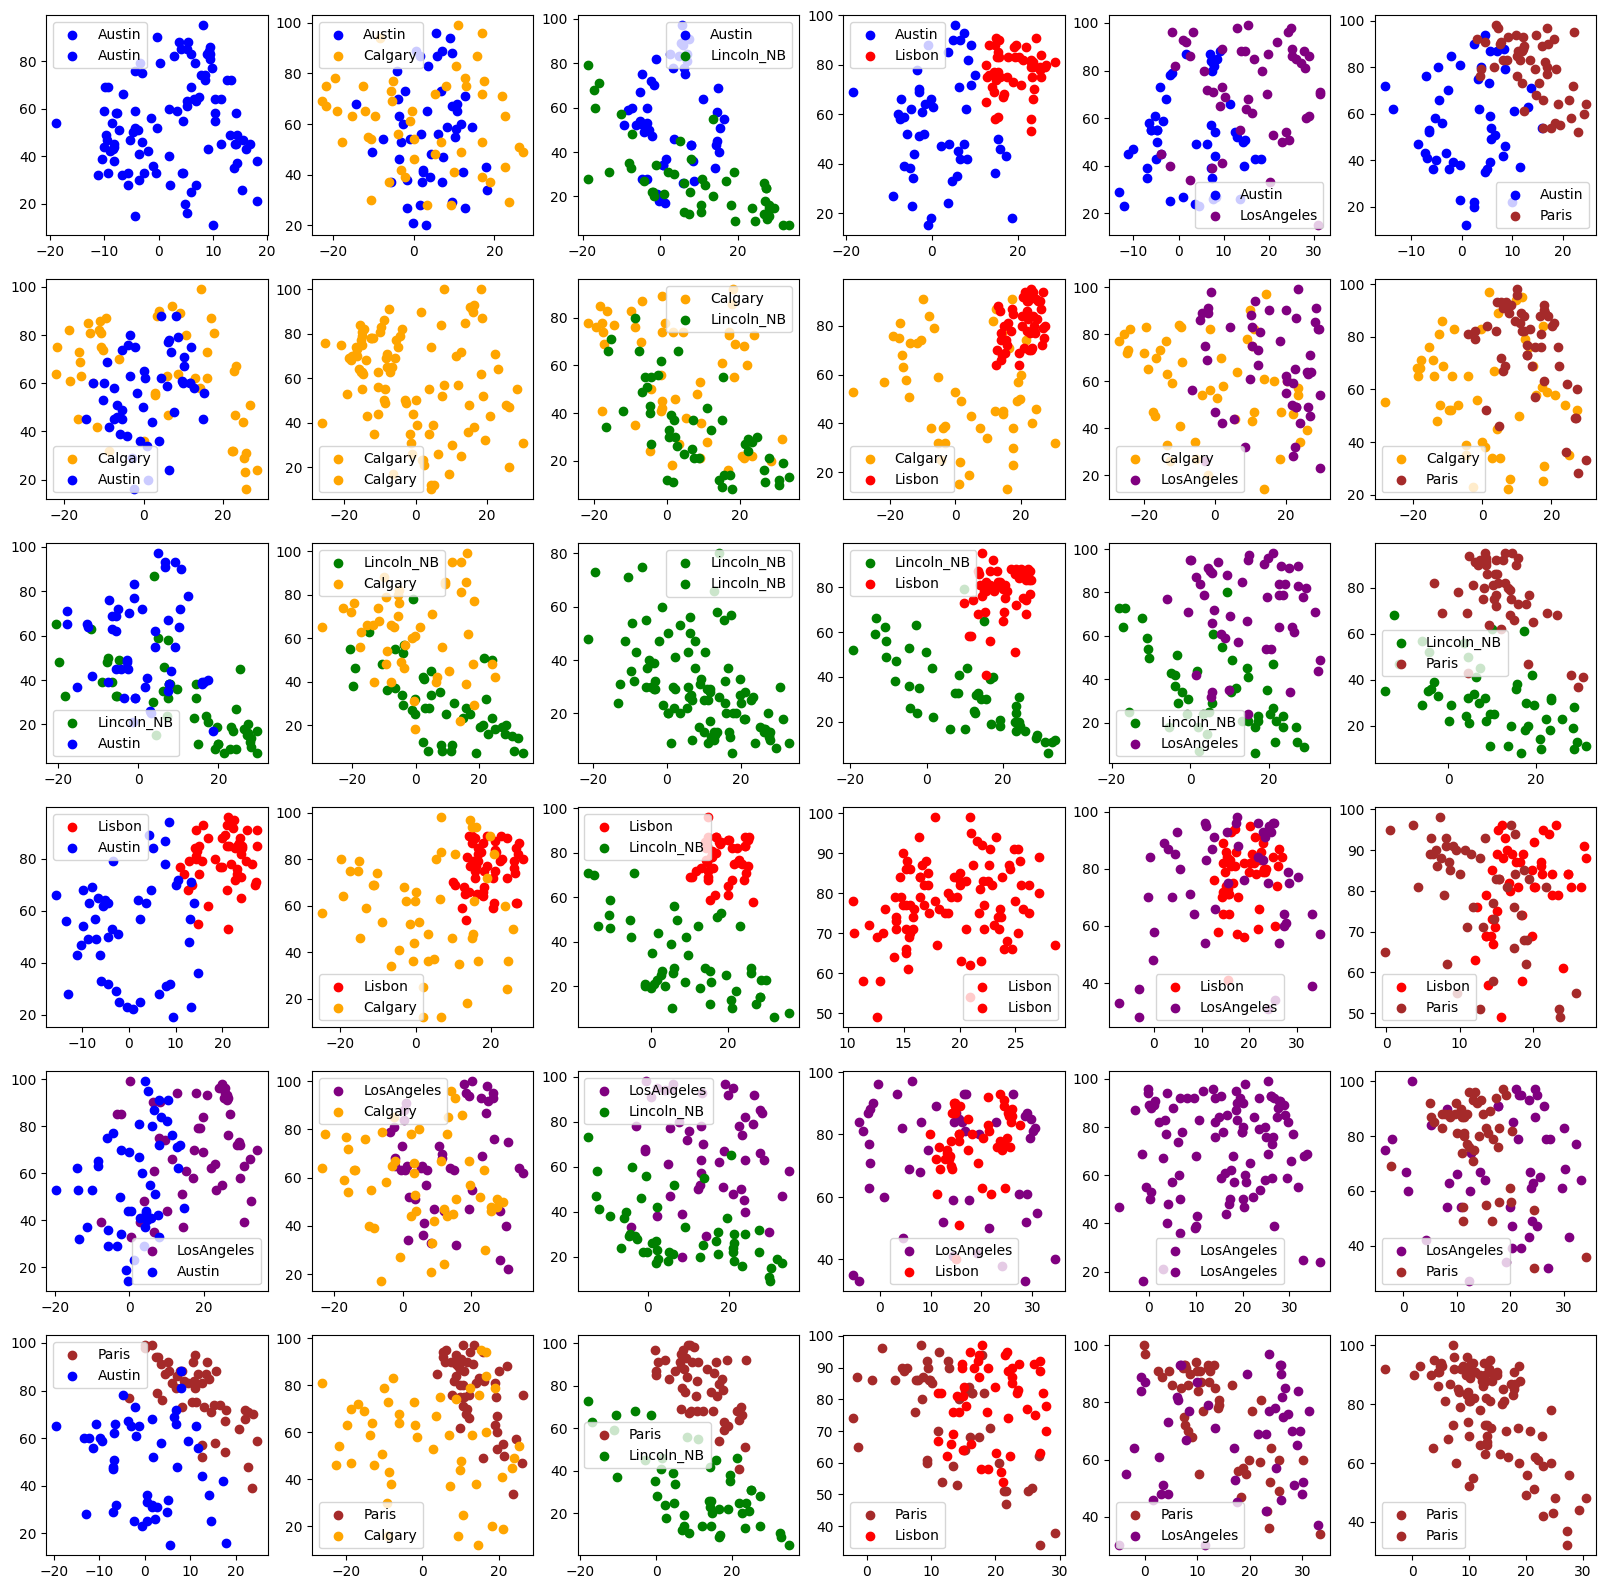

In [31]:
# 2 x 2 
df_2d = pd.DataFrame()
df_2d["temperature_2m"] = df_cities["temperature_2m"].values
df_2d["relative_humidity_2m"] = df_cities["relative_humidity_2m"].values
df_2d["city"] = df_cities['city'].values
fig, ax = plt.subplots(nrows=n_cities, ncols=n_cities, figsize=(20,20))
for i, city1 in enumerate(cities):
    for j, city2 in enumerate(cities):
        for city in [city1, city2]:
            df_city = df_2d[df_2d["city"] == city]
            df_city = df_city.sample(50)
            ax[i][j].scatter(df_city["temperature_2m"].values, df_city["relative_humidity_2m"].values, label=city, color=colors[city])
        ax[i][j].legend()
plt.show()

## Full PCA

n_components = 1, R^2 = 0.22747548739274848
n_components = 2, R^2 = 0.3758728989879635
n_components = 3, R^2 = 0.48067363211998776
n_components = 4, R^2 = 0.578237529995545
n_components = 5, R^2 = 0.6583591509916579
n_components = 6, R^2 = 0.7323453354000182
n_components = 7, R^2 = 0.7992734805660369
n_components = 8, R^2 = 0.8622902775169496
n_components = 9, R^2 = 0.921004296908582
n_components = 10, R^2 = 0.959852569624304
n_components = 11, R^2 = 0.9913621837658677
n_components = 12, R^2 = 0.999344761785111


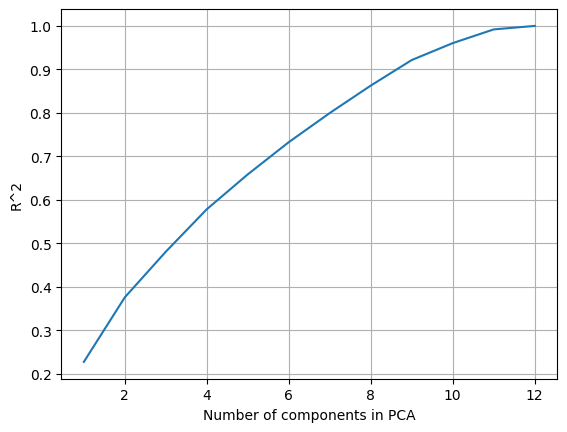

In [32]:
n_components_arr = np.arange(1,X_train_scaled.shape[1])
r2_arr = []
for n_components in n_components_arr:
    pca_n = PCA(n_components=n_components)
    pca_n.fit(X_train_scaled)
    Xhat_test = ss.inverse_transform(pca_n.inverse_transform(pca_n.transform(ss.transform(X_test))))
    r2 = r2_score(y_true=X_test, y_pred=Xhat_test)
    r2_arr.append(r2)
    print(f"n_components = {n_components}, R^2 = {r2}")
plt.plot(n_components_arr, r2_arr)
plt.xlabel("Number of components in PCA")
plt.ylabel("R^2")
plt.grid(True)
plt.show()

In [38]:
pca_10 = PCA(n_components=10)
pca_10.fit(X_train_scaled)
X_pca10 = pca_10.transform(ss.transform(X.values))
for i in range(10):
    data[f"pca_x{i}"] = X_pca10[:,i]

# Kernel PCA on data

To speed up the Kernel PCA, the size of the data is reduced. So we randonly select 1% of the of the data from X_train:

In [36]:
indices = np.random.choice(len(X_train_scaled), size=len(X_train_scaled)//20, replace=False) 
# replace=False causes the indices to be unique and non-repeated.
X_train_scaled_compact = X_train_scaled[indices, :]

n_components = 1, R^2 = 0.21023326799553133
n_components = 2, R^2 = 0.34507502889598585
n_components = 3, R^2 = 0.43547663797431624
n_components = 4, R^2 = 0.5165013869226663
n_components = 5, R^2 = 0.5870174719667938
n_components = 6, R^2 = 0.6548342223286088
n_components = 7, R^2 = 0.7284742549946347
n_components = 8, R^2 = 0.7580304934996538
n_components = 9, R^2 = 0.7818952222513196
n_components = 10, R^2 = 0.7882919971035219
n_components = 11, R^2 = 0.799911170766404
n_components = 12, R^2 = 0.8019887015485655


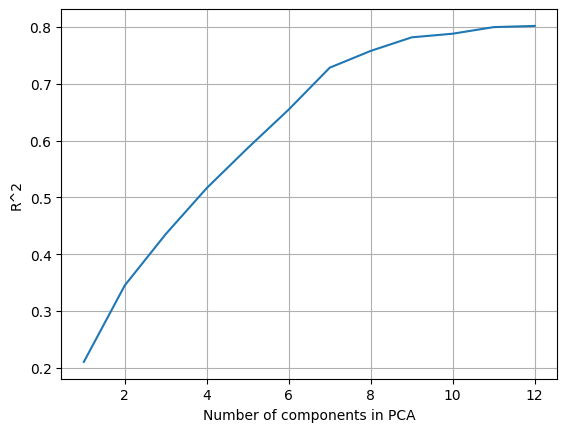

In [110]:
n_components_arr = np.arange(1,X_train_scaled.shape[1])
r2_arr = []
for n_components in n_components_arr:
    kpca_n = KernelPCA(n_components=n_components, 
                       kernel='rbf', 
                       gamma=None, 
                       fit_inverse_transform=True, 
                       alpha=0.1,
    )
    kpca_n.fit(X_train_scaled_compact)
    Xhat_test = ss.inverse_transform(kpca_n.inverse_transform(kpca_n.transform(ss.transform(X_test))))
    r2 = r2_score(y_true=X_test, y_pred=Xhat_test)
    r2_arr.append(r2)
    print(f"n_components = {n_components}, R^2 = {r2}")
plt.plot(n_components_arr, r2_arr)
plt.xlabel("Number of components in PCA")
plt.ylabel("R^2")
plt.grid(True)
plt.show()

# Kernel PCA on X_pca10

In [64]:
X_train2, X_test2 = train_test_split(X_pca10, test_size=0.95, random_state=123, stratify=df_cities["city"].values)
test_indices = np.random.choice(len(X_test2), size=len(X_test2)//20, replace=False)
ss2 = StandardScaler()
X_train2_scaled = ss2.fit_transform(X_train2)

n_components = 1, R^2 = 0.10582284514594735
n_components = 2, R^2 = 0.20523066303814938
n_components = 3, R^2 = 0.3037889472377904
n_components = 4, R^2 = 0.411766669336538
n_components = 5, R^2 = 0.5254285821595063
n_components = 6, R^2 = 0.6219631943012434
n_components = 7, R^2 = 0.7112436947356632
n_components = 8, R^2 = 0.7738373074506149
n_components = 9, R^2 = 0.8011876624461566


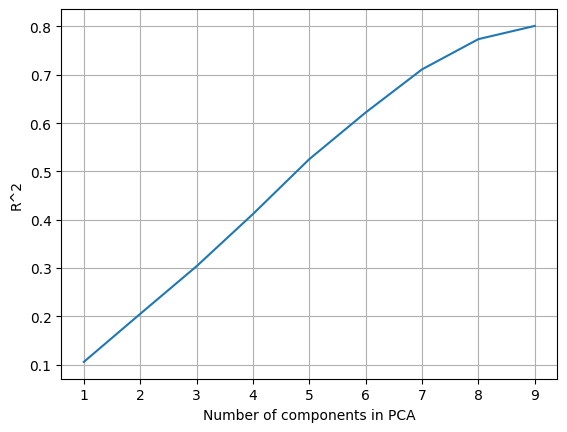

In [81]:
n_components_arr = np.arange(1,X_train2_scaled.shape[1])
r2_arr = []
for n_components in n_components_arr:
    kpca_n = KernelPCA(n_components=n_components, kernel='rbf', gamma=None, fit_inverse_transform=True, alpha=0.1)
    kpca_n.fit(X_train2_scaled)
    Xhat_test2 = ss2.inverse_transform(kpca_n.inverse_transform(kpca_n.transform(ss2.transform(X_test2[test_indices,:]))))
    r2 = r2_score(y_true=X_test2[test_indices,:], y_pred=Xhat_test2)
    r2_arr.append(r2)
    print(f"n_components = {n_components}, R^2 = {r2}")
plt.plot(n_components_arr, r2_arr)
plt.xlabel("Number of components in PCA")
plt.ylabel("R^2")
plt.grid(True)
plt.show()

# MDS on data

In [41]:
indices = np.random.choice(len(data), size=5000, replace=False) # replace=False causes the indices to be unique and non-repeated.
data_scaled_compact = ss.transform(X.values[indices, :])

In [35]:
t0 = time.time()
n_components = 2
print(f"n_components = {n_components}")
embedding = MDS(n_components=n_components, n_init=1, verbose=1, random_state=42)
X_embedding = embedding.fit_transform(data_scaled_compact)
t1 = time.time()
print(f"---DONE, t = {t1-t0} sec ----")
print(f"X_embedding.shape = {X_embedding.shape}")

n_components = 2
---DONE, t = 172.08329892158508 sec ----
X_embedding.shape = (5000, 2)


df_mds sample =         mds_x1    mds_x2        city
1850 -0.905613  1.807000     Calgary
3051  1.951047 -3.005184      Austin
2410 -1.955486  2.109397      Lisbon
392   0.560790 -2.343182      Austin
1536 -0.077929  2.674696       Paris
2874 -2.256379 -2.308252  Lincoln_NB
1234 -1.861228  1.139785       Paris
4817 -0.382350  3.351087  LosAngeles
2524 -1.298580 -2.293404      Austin
1737 -0.167864  0.120733  LosAngeles
4793  0.057819 -0.958376     Calgary
1004 -0.688577  1.930619      Lisbon
4710  0.864277 -0.023672     Calgary
4525 -1.015654 -0.983996     Calgary
4047 -0.790702 -1.414893      Austin
3007  2.910497 -2.643876     Calgary
3683  3.985055 -2.222377     Calgary
1799  2.935761 -1.477396  LosAngeles
4263  6.294827 -1.686333     Calgary
717  -2.184083 -2.479244  Lincoln_NB

Number of entries for Austin = 903

Number of entries for Calgary = 936

Number of entries for Lincoln_NB = 443

Number of entries for Lisbon = 841

Number of entries for LosAngeles = 934

Number of entries

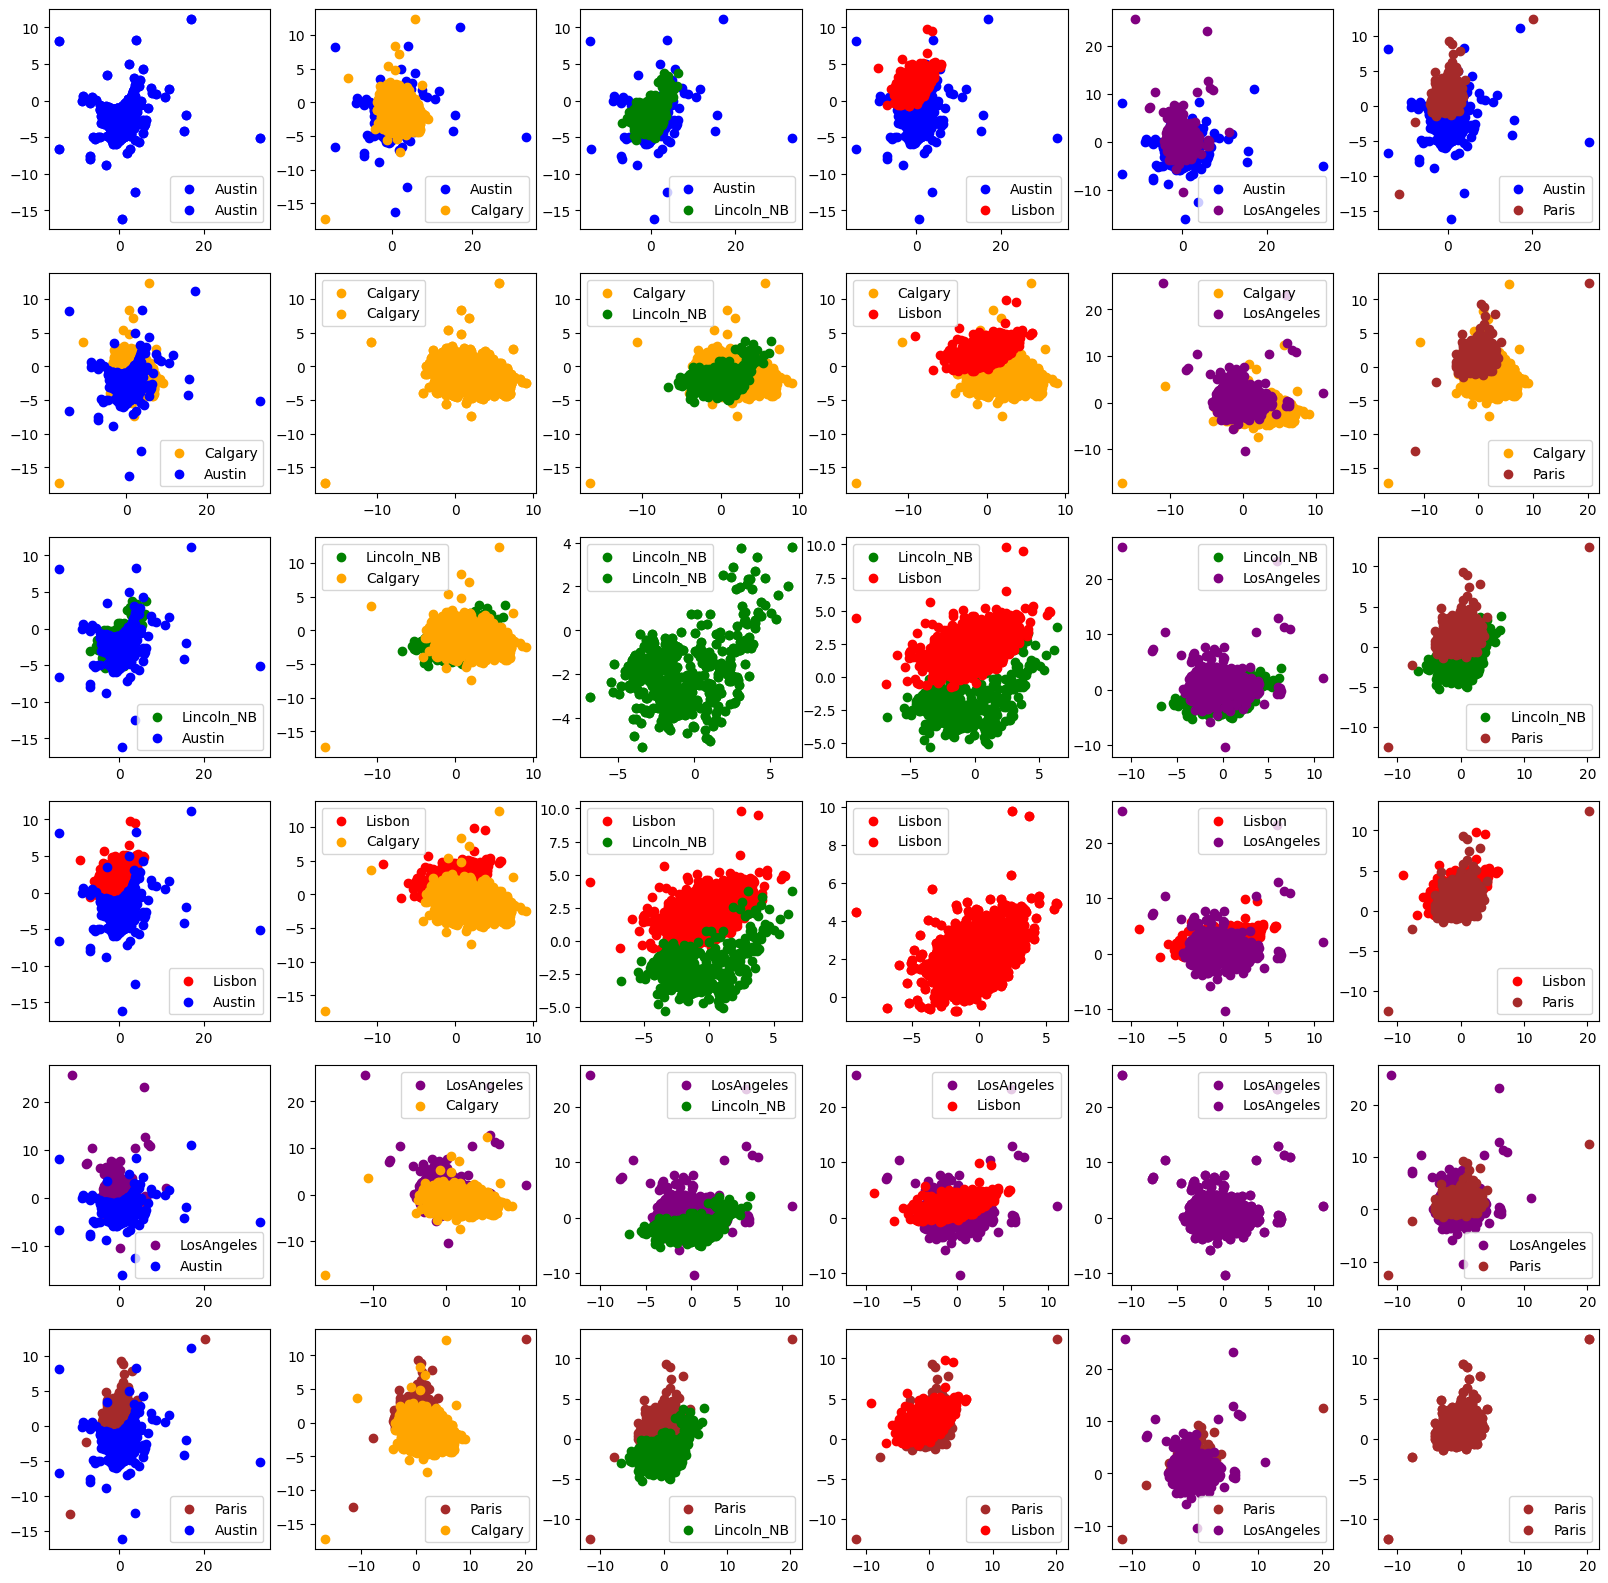

In [36]:
df_mds = pd.DataFrame()
df_mds["mds_x1"] = X_embedding[:,0]
df_mds["mds_x2"] = X_embedding[:,1]
df_mds["city"] = df_cities['city'].values[indices]
print(f"df_mds sample = {df_mds.sample(20)}")
for city in cities:
    df_city = df_mds[df_mds["city"] == city]
    print(f"\nNumber of entries for {city} = {len(df_city)}")
fig, ax = plt.subplots(nrows=n_cities, ncols=n_cities, figsize=(20,20))
for i, city1 in enumerate(cities):
    for j, city2 in enumerate(cities):
        for city in [city1, city2]:
            df_city = df_mds[df_mds["city"] == city]
            # df_city = df_city.sample(50)
            ax[i][j].scatter(df_city["mds_x1"].values, df_city["mds_x2"].values, label=city, color=colors[city])
        ax[i][j].legend()
plt.show()

# KNN Clustering

https://scikit-learn.org/stable/modules/clustering.html

In [37]:
n_cities = len(cities)
print(f"n_cities = {n_cities}")
kmeans = KMeans(n_clusters=n_cities, random_state=0)
kmeans.fit(X_train_mmscaled)
print(f"Labels = {set(kmeans.labels_)}")
test_labels = kmeans.predict(mms.transform(X_test))
df_knn = pd.DataFrame()
df_knn["cluster_label"] = test_labels
df_knn["city"] = df_cities["city"].values[indices_test]
df_knn["city_code"] = le.transform(df_knn["city"].values)
for feature_name in encoded_feature_names:
    df_knn[feature_name] = df_cities[feature_name].values[indices_test]
df_knn.sample(10)

n_cities = 6
Labels = {0, 1, 2, 3, 4, 5}


,cluster_label,city,city_code,city_Austin,city_Calgary,city_Lincoln_NB,city_Lisbon,city_LosAngeles,city_Paris
16102,1,LosAngeles,4,0.0,0.0,0.0,0.0,1.0,0.0
12563,4,Paris,5,0.0,0.0,0.0,0.0,0.0,1.0
14798,1,Paris,5,0.0,0.0,0.0,0.0,0.0,1.0
16391,5,Austin,0,1.0,0.0,0.0,0.0,0.0,0.0
16720,4,Calgary,1,0.0,1.0,0.0,0.0,0.0,0.0
4101,5,Austin,0,1.0,0.0,0.0,0.0,0.0,0.0
17156,2,Paris,5,0.0,0.0,0.0,0.0,0.0,1.0
4407,1,Paris,5,0.0,0.0,0.0,0.0,0.0,1.0
9242,2,Calgary,1,0.0,1.0,0.0,0.0,0.0,0.0
12333,2,Calgary,1,0.0,1.0,0.0,0.0,0.0,0.0


Quantitative metrics

Adjusted Rand Index (ARI): Calculates a score that accounts for chance, giving a similarity score between two clusterings. A score near 1 means the clusterings are very similar. 


Normalized Mutual Information (NMI): Measures the mutual information between two clusterings and normalizes it. A score near 1 indicates high similarity. 
Pairwise comparison


Contingency Matrix: Create a matrix that shows the number of data points in each pair of clusters from the two clusterings. 

In [38]:
ari = adjusted_rand_score(df_knn["city_code"] , df_knn["cluster_label"])
print(f"Adjusted Rand Index (ARI) = {ari}")
nmi = normalized_mutual_info_score(df_knn["city_code"] , df_knn["cluster_label"])
print(f"Normalized Mutual Information (NMI) = {nmi}")
cmat = contingency_matrix(labels_true=df_knn["city_code"] , labels_pred=df_knn["cluster_label"])
cmat_df = pd.DataFrame(columns=["city"] + [f"cluster-{i}" for i in range(6)])
cmat_df["city"] = cities
cmat_df.iloc[:,1:] = cmat
print(f"Contingency Matrix:")
cmat_df

Adjusted Rand Index (ARI) = 0.15625048350832024
Normalized Mutual Information (NMI) = 0.27500512111164327
Contingency Matrix:


,city,cluster-0,cluster-1,cluster-2,cluster-3,cluster-4,cluster-5
0,Austin,0,0,0,1823,0,1645
1,Calgary,384,877,737,0,483,1054
2,Lincoln_NB,211,290,406,2,159,719
3,Lisbon,1112,654,550,0,1199,0
4,LosAngeles,817,1174,755,0,783,19
5,Paris,579,1321,1031,0,512,0


In [39]:
data["cluster_label"] = kmeans.predict(mms.transform(X.values))
encoder2 = OneHotEncoder(sparse_output=False)
encoded_cluster_labels = encoder2.fit_transform(data[["cluster_label"]])
encoder2_feature_names = encoder2.get_feature_names_out()
encoder2_df = pd.DataFrame(encoded_cluster_labels, columns=encoder2_feature_names)
data = pd.concat([data, encoder2_df], axis = 1)
df_cities.shape
data.sample(10)

,temperature_2m,relative_humidity_2m,precipitation,snowfall,snow_depth,dew_point_2m,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,...,city_Lisbon,city_LosAngeles,city_Paris,cluster_label,cluster_label_0,cluster_label_1,cluster_label_2,cluster_label_3,cluster_label_4,cluster_label_5
44273,10.8,80,2.0,0.0,0.00,7.4,36.1,287,59.8,78,...,1.0,0.0,0.0,2,0.0,0.0,1.0,0.0,0.0,0.0
12175,10.6,44,0.2,0.0,0.00,-1.2,5.9,52,28.1,100,...,0.0,0.0,0.0,3,0.0,0.0,0.0,1.0,0.0,0.0
67685,26.5,61,0.0,0.0,0.00,18.4,21.9,14,44.6,77,...,0.0,1.0,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0
95637,7.5,94,0.0,0.0,0.00,6.5,10.5,175,20.5,61,...,0.0,0.0,1.0,1,0.0,1.0,0.0,0.0,0.0,0.0
62231,-2.1,89,0.0,0.0,0.00,-3.7,7.9,133,13.0,0,...,0.0,1.0,0.0,4,0.0,0.0,0.0,0.0,1.0,0.0
35836,-4.1,26,0.0,0.0,0.01,-21.0,11.9,92,20.9,100,...,0.0,0.0,0.0,2,0.0,0.0,1.0,0.0,0.0,0.0
8360,-0.8,46,0.0,0.0,0.03,-11.1,10.3,234,50.4,0,...,0.0,0.0,0.0,5,0.0,0.0,0.0,0.0,0.0,1.0
65589,21.2,94,0.6,0.0,0.00,20.2,11.5,58,20.9,100,...,0.0,1.0,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0
31695,18.7,73,0.0,0.0,0.00,13.7,10.0,206,13.7,0,...,0.0,0.0,0.0,4,0.0,0.0,0.0,0.0,1.0,0.0
94191,14.0,70,0.0,0.0,0.00,8.6,17.8,232,42.1,100,...,0.0,0.0,1.0,1,0.0,1.0,0.0,0.0,0.0,0.0


<Axes: >

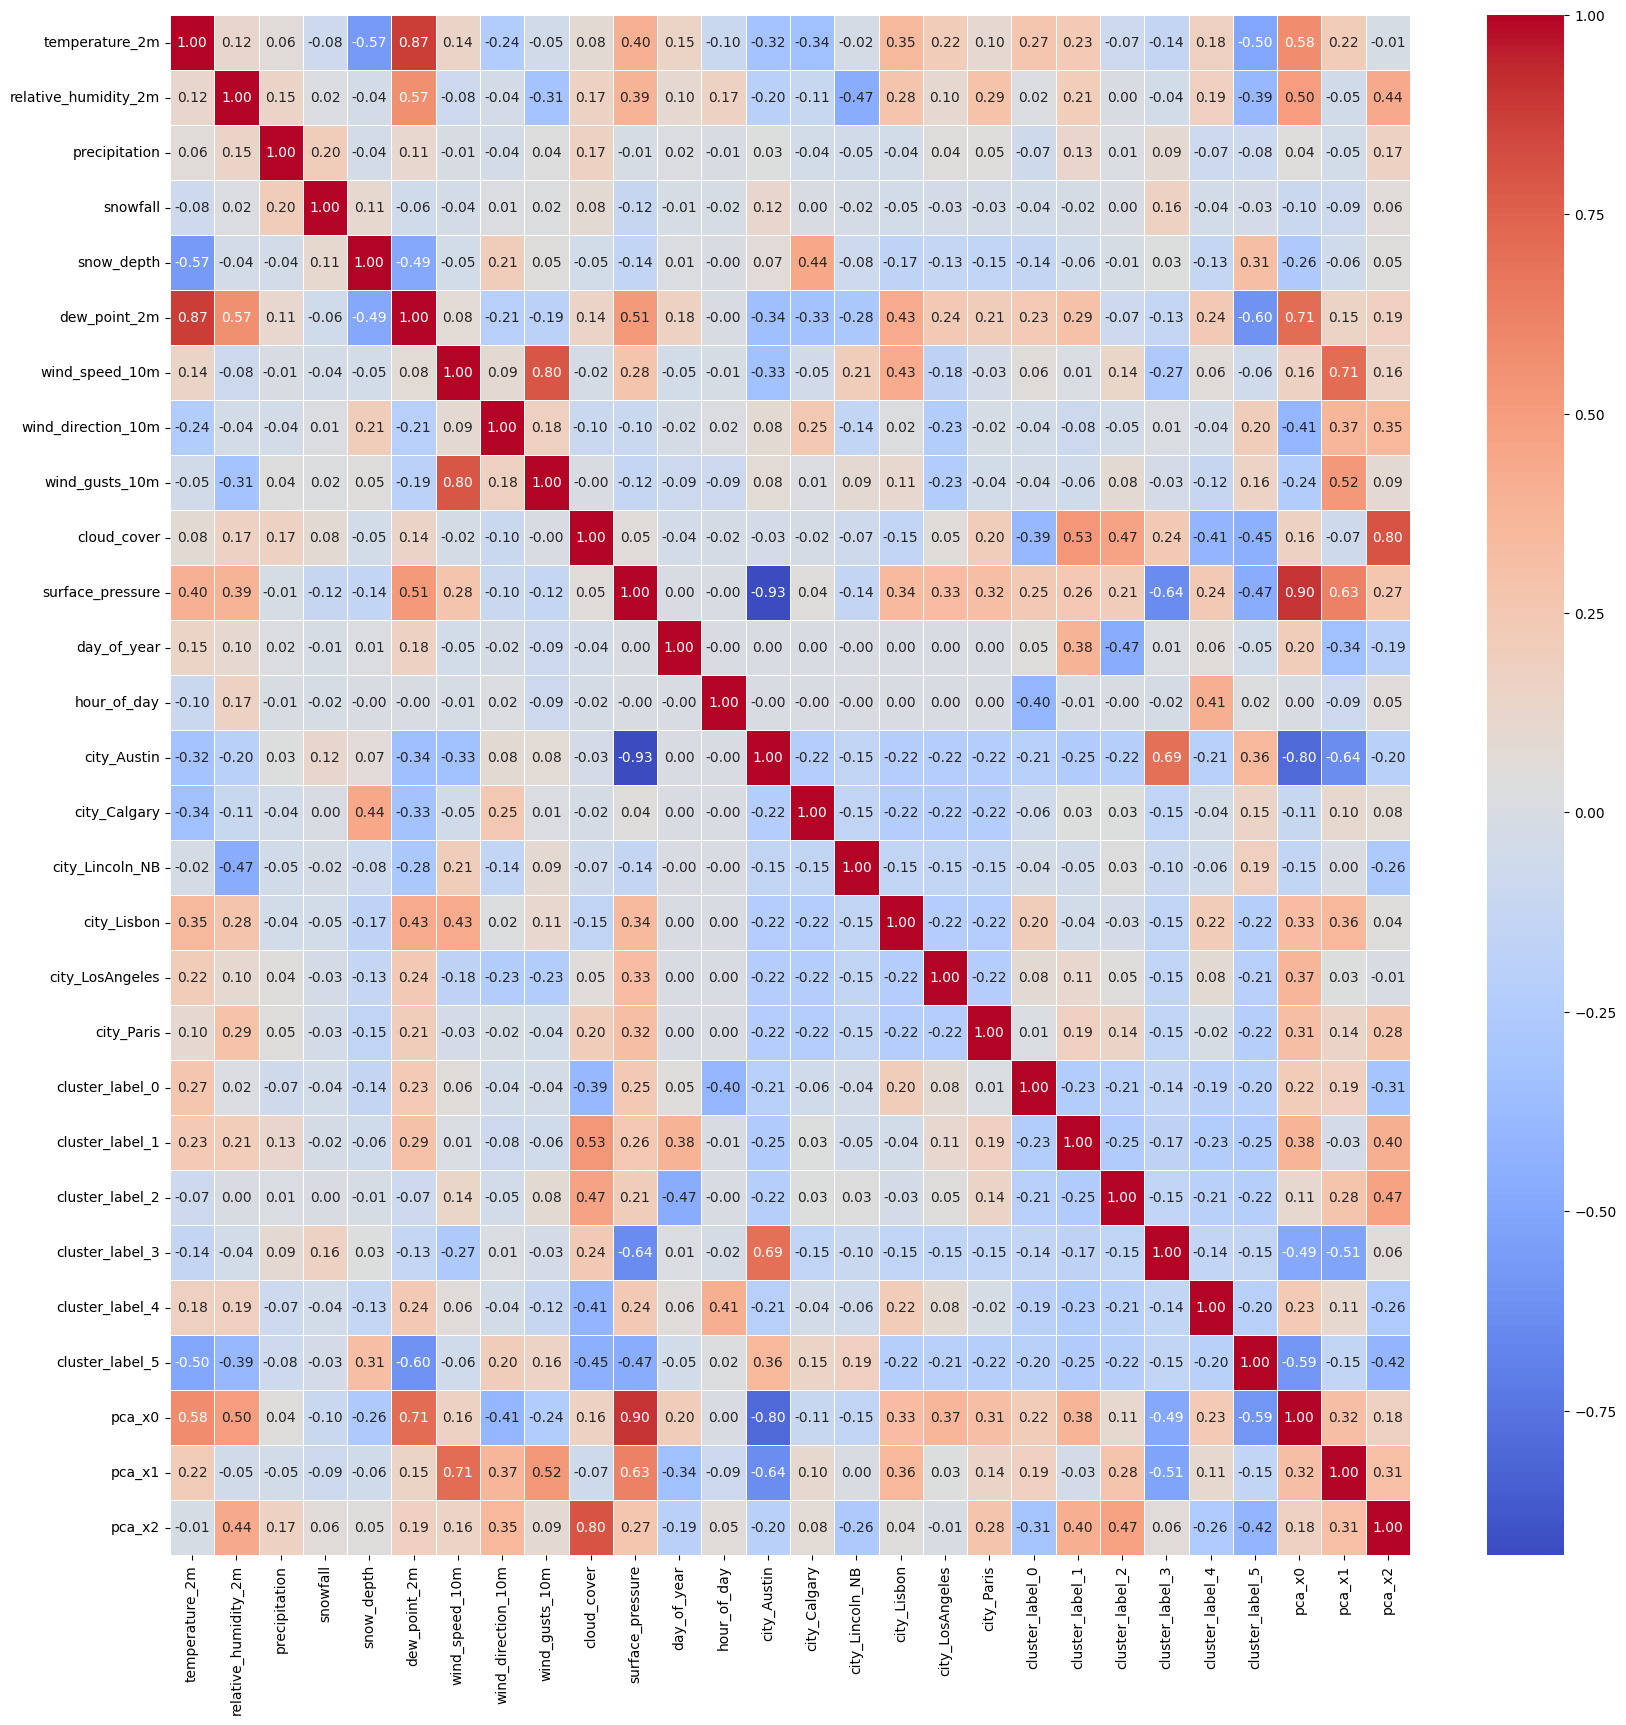

In [146]:
data_corr_matrix = data.drop(columns=["cluster_label"]).corr()
plt.figure(figsize=(20, 20)) # Adjust figure size as needed
sns.heatmap(data_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# DBSCAN

In [59]:
t0 = time.time()
dbscan = DBSCAN(eps=3.0, min_samples=2)
dbscan.fit(pca_10.transform(X_train_scaled))
t1 = time.time()
print(f"---DONE, t = {t1-t0} sec ----")

---DONE, t = 229.9099462032318 sec ----


In [60]:
n_clusters = len(set(dbscan.labels_))
print(f" Number of clusters (inclusing noise) = {n_clusters}")
noise = (dbscan.labels_ == -1)
noise_percent = np.sum(noise) / len(noise) * 100.0
print(f"Noise: {noise_percent}")
for i in range(n_clusters - 1):
    label_i = (dbscan.labels_ == i)
    label_i_percent = np.sum(label_i) / len(label_i) * 100.0
    print(f"Label {i}: {label_i_percent}")

 Number of clusters (inclusing noise) = 11
Noise: 0.04275497512437811
Label 0: 99.92485489220564
Label 1: 0.002591210613598673
Label 2: 0.00777363184079602
Label 3: 0.002591210613598673
Label 4: 0.005182421227197346
Label 5: 0.002591210613598673
Label 6: 0.002591210613598673
Label 7: 0.00388681592039801
Label 8: 0.002591210613598673
Label 9: 0.002591210613598673


# Mean Shift

In [61]:
indices = np.random.choice(len(data), size=10000, replace=False) # replace=False causes the indices to be unique and non-repeated.
X_scaled_compact = ss.transform(X.values[indices, :])
print(f"X size = {X.shape}, X_scaled_compact size = {X_scaled_compact.shape}, compaction = {len(X_scaled_compact) / len(X) * 100} %")

X size = (96480, 13), X_scaled_compact size = (10000, 13), compaction = 10.364842454394694 %


In [62]:
t0 = time.time()
mean_shift = MeanShift() # bandwidth
mean_shift.fit(pca_10.transform(X_scaled_compact))
t1 = time.time()
print(f"---DONE, t = {t1-t0} sec ----")

---DONE, t = 75.70152449607849 sec ----


In [63]:
n_clusters = len(set(mean_shift.labels_))
print(f" Number of clusters (inclusing noise) = {n_clusters}")
for i in range(n_clusters):
    label_i = (mean_shift.labels_ == i)
    label_i_percent = np.sum(label_i) / len(label_i) * 100.0
    print(f"Label {i}: {label_i_percent}")

 Number of clusters (inclusing noise) = 14
Label 0: 99.24
Label 1: 0.37
Label 2: 0.21
Label 3: 0.04
Label 4: 0.02
Label 5: 0.02
Label 6: 0.02
Label 7: 0.01
Label 8: 0.01
Label 9: 0.01
Label 10: 0.01
Label 11: 0.01
Label 12: 0.01
Label 13: 0.02
